# Validação independente das explicações XAI

No notebook 03_analise_xai.ipynb, avaliamos as explicações SHAP e LIME por meio de implementações próprias de Fidelity, Infidelity, Stability, Sparsity e Completeness. Neste notebook, validaremos essas cinco propriedades com métricas de bibliotecas adequadas ao problema de regressão temporal de RUL. Usamos **Xplique** para Fidelity e **Quantus** para Infidelity; as demais propriedades serão avaliadas conforme a compatibilidade das implementações.

Quando a biblioteca permite reproduzir o mesmo protocolo, comparamos os valores numéricos para verificar a implementação própria. Diferenças de perturbações, amostras ou agregação precisam ser explicitadas antes de interpretar divergências. A concordância entre implementações verifica o cálculo; a qualidade das explicações depende dos resultados de cada métrica.

In [15]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from xplique.metrics import Deletion

sys.path.append(os.path.abspath('../..')) 

from src.xai.xai_baseExplainer import BaseExplainer
from src.xai.xai_shapExplainer import ShapExplainer
from src.xai.xai_limeExplainer import LimeExplainer
from src.xai.xai_igExplainer import IntegratedGradientsExplainer
from src.xai.xai_timeshapExplainer import TimeShapExplainer
from src.xai.xai_windowshapExplainer import WindowShapExplainer
from src.xai.xaI_gradcamExplainer import GradCamExplainer
from src.xai.xai_saliencymapsExplainer import SaliencyMapsExplainer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
DATASET_01 = "FD001"
model_path_001 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_01}.keras"
x_path_001 = f"../../data/processed_data/X_test_{DATASET_01}.npz"
y_path_001 = f"../../data/processed_data/y_test_{DATASET_01}.npz"

DATASET_02 = "FD002"
model_path_002 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_02}.keras"
x_path_002 = f"../../data/processed_data/X_test_{DATASET_02}.npz"
y_path_002 = f"../../data/processed_data/y_test_{DATASET_02}.npz"

DATASET_03 = "FD003"
model_path_003 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_03}.keras"
x_path_003 = f"../../data/processed_data/X_test_{DATASET_03}.npz"
y_path_003 = f"../../data/processed_data/y_test_{DATASET_03}.npz"

DATASET_04 = "FD004"
model_path_004 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_04}.keras"
x_path_004 = f"../../data/processed_data/X_test_{DATASET_04}.npz"
y_path_004 = f"../../data/processed_data/y_test_{DATASET_04}.npz"

## 1. Fidelity: as importâncias atribuídas acompanham o impacto real dos sensores?

No notebook anterior, verificamos Fidelity mascarando os sensores mais e menos importantes segundo o SHAP e observando a alteração do MAE e do RMSE. Aqui, usaremos a métrica Deletion do Xplique para validar o mesmo protocolo de remoção ordenada.

- Deletion: remove progressivamente as variáveis de acordo com a ordem de importância atribuída pela explicação e mede como o erro do modelo se altera.

Neste problema de regressão, a métrica será aplicada ao erro absoluto: a remoção MoRF deve aumentar o erro mais rapidamente que a remoção LeRF. Serão comparadas as curvas e suas AUCs normalizadas com os resultados obtidos no notebook anterior.

In [17]:
def obter_shap_assinado(explainer, X):
    """Retorna SHAP no formato (amostras, tempo, sensores), preservando o sinal."""
    valores = explainer.explainer.shap_values(X.astype(np.float32))
    if isinstance(valores, list):
        valores = valores[0]
    valores = np.asarray(valores)
    return valores[..., 0] if valores.ndim == 4 else valores

def criar_adapter_por_sensor(modelo, formato_original):
    """Recebe (sensor, 1, tempo), mascarando cada sensor em todos os ciclos de uma vez."""
    n_tempo, n_sensores = formato_original
    entrada = tf.keras.Input(shape=(n_sensores, 1, n_tempo))
    sem_dim_unitaria = tf.keras.layers.Lambda(lambda x: tf.squeeze(x, axis=2))(entrada)
    formato_original = tf.keras.layers.Lambda(lambda x: tf.transpose(x, perm=[0, 2, 1]))(sem_dim_unitaria)
    return tf.keras.Model(entrada, modelo(formato_original))

def preparar_deletion_por_sensor(explainer, X_train, num_instancias=1000):
    """Prepara entradas e ranking global para uma remoção por sensor completo."""
    n = min(num_instancias, len(explainer.X_test))
    X_original = explainer.X_test[:n].astype(np.float32)
    # Mesmo protocolo do notebook 03: SHAP por janela e soma dos valores absolutos por sensor.
    importancia_global = np.zeros(X_original.shape[2])
    for indice in range(n):
        atribuicao = np.asarray(explainer.explain_instance(indice))
        atribuicao = atribuicao[0, :, :, 0] if atribuicao.ndim == 4 else atribuicao[0]
        importancia_global += np.sum(np.abs(atribuicao), axis=0)
    importancia_global /= n
    n_tempo, n_sensores = X_original.shape[1:]
    X = np.transpose(X_original, (0, 2, 1))[:, :, np.newaxis, :]
    explicacao_morf = np.broadcast_to(importancia_global.reshape(1, n_sensores, 1, 1), (n, n_sensores, 1, n_tempo)).astype(np.float32)
    referencia = np.median(X_train, axis=(0, 1)).reshape(1, n_sensores, 1, 1).astype(np.float32)
    y = explainer.y_test[:n].reshape(-1, 1).astype(np.float32)
    modelo = criar_adapter_por_sensor(explainer.model, X_original.shape[1:])
    return X, explicacao_morf, referencia, y, modelo

def avaliar_deletion_morf_lerf(explainer, X_train, num_instancias=1000, max_k=10):
    """Valida MoRF e LeRF com a implementação Deletion do Xplique."""
    X, explicacao_morf, referencia, y, modelo = preparar_deletion_por_sensor(explainer, X_train, num_instancias)
    max_k = min(max_k, X.shape[1])

    def baseline_mediana(entradas):
        return np.broadcast_to(referencia, np.shape(entradas)).astype(np.float32)

    def operador_erro_negativo(modelo, entradas, alvos):
        previsoes = tf.squeeze(modelo(entradas), axis=-1)
        return -tf.abs(previsoes - tf.squeeze(alvos, axis=-1))

    metrica = Deletion(
        modelo, X, targets=y, batch_size=16, baseline_mode=baseline_mediana,
        steps=max_k, max_percentage_perturbed=max_k / X.shape[1],
        operator=operador_erro_negativo, activation=None,
    )
    resultados = []
    for estrategia, explicacao in {'MoRF (SHAP)': explicacao_morf, 'LeRF (SHAP invertido)': -explicacao_morf}.items():
        scores = metrica.detailed_evaluate(explicacao)
        curva = pd.DataFrame({'Sensores removidos (k)': list(scores.keys()), 'MAE': -np.asarray(list(scores.values()))})
        mae_original = curva['MAE'].iloc[0]
        curva['Delta MAE relativo'] = (curva['MAE'] - mae_original) / mae_original
        curva['Estratégia'] = estrategia
        resultados.append(curva)
    resultados = pd.concat(resultados, ignore_index=True)
    resumo = []
    for estrategia, grupo in resultados.groupby('Estratégia'):
        grupo = grupo.sort_values('Sensores removidos (k)')
        escala_k = grupo['Sensores removidos (k)'] / grupo['Sensores removidos (k)'].max()
        resumo.append({'Estratégia': estrategia, 'AUC do aumento relativo de MAE': np.trapezoid(grupo['Delta MAE relativo'], x=escala_k)})
    resumo = pd.DataFrame(resumo)
    auc_morf = resumo.loc[resumo['Estratégia'] == 'MoRF (SHAP)', 'AUC do aumento relativo de MAE'].iloc[0]
    auc_lerf = resumo.loc[resumo['Estratégia'] == 'LeRF (SHAP invertido)', 'AUC do aumento relativo de MAE'].iloc[0]
    return resultados, resumo, auc_morf - auc_lerf

def plotar_deletion_morf_lerf(resultados, dataset):
    plt.figure(figsize=(7, 4))
    for estrategia, grupo in resultados.groupby('Estratégia'):
        plt.plot(grupo['Sensores removidos (k)'], grupo['MAE'], marker='o', label=estrategia)
    plt.xlabel('Número de sensores removidos (k)'); plt.ylabel('MAE')
    plt.title(f'Deletion do Xplique: MoRF versus LeRF - {dataset}')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

,Estratégia,AUC do aumento relativo de MAE
0,LeRF (SHAP invertido),0.011
1,MoRF (SHAP),0.087


Diferença AUC MoRF - LeRF: 0.0758


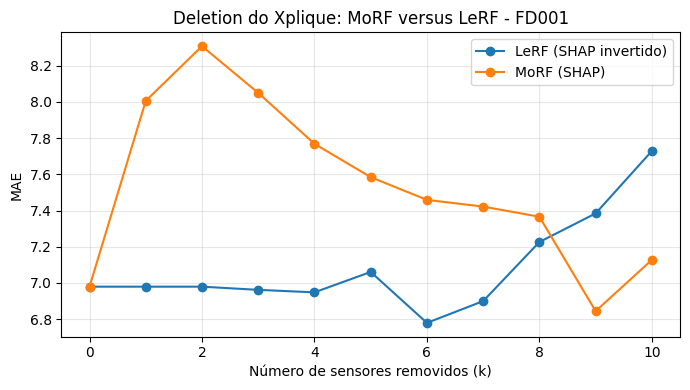

In [18]:
NUM_INSTANCIAS = 1000
MAX_K = 10

X_train_fd001 = np.load('../../data/processed_data/X_train_FD001.npz')['dados']
shap_fd001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)

resultados_deletion_fd001, auc_deletion_fd001, diferenca_auc_deletion_fd001 = avaliar_deletion_morf_lerf(
    shap_fd001, X_train_fd001, num_instancias=NUM_INSTANCIAS, max_k=MAX_K
)

display(auc_deletion_fd001.round(3))
print(f'Diferença AUC MoRF - LeRF: {diferenca_auc_deletion_fd001:.4f}')
plotar_deletion_morf_lerf(resultados_deletion_fd001, 'FD001')

### Análise - FD001

O Xplique obteve AUC de MAE igual a 0,087 para MoRF e 0,011 para LeRF, com diferença de 0,076. Como MoRF ficou acima de LeRF, os sensores no topo do ranking SHAP têm maior impacto no erro. A separação é positiva, porém menor que nos outros FDs, sugerindo que a importância está mais distribuída entre os sensores. Os valores coincidem com os do notebook 03 após a padronização das 1000 janelas, do ranking global e da mediana.

,Estratégia,AUC do aumento relativo de MAE
0,LeRF (SHAP invertido),0.003
1,MoRF (SHAP),0.221


Diferença AUC MoRF - LeRF: 0.2179


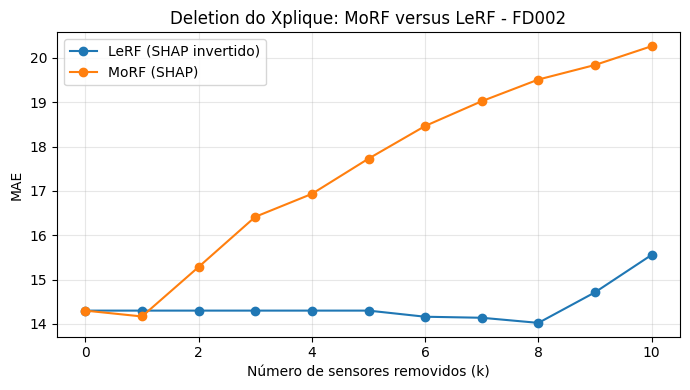

In [19]:
X_train_fd002 = np.load('../../data/processed_data/X_train_FD002.npz')['dados']
shap_fd002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)

resultados_deletion_fd002, auc_deletion_fd002, diferenca_auc_deletion_fd002 = avaliar_deletion_morf_lerf(
    shap_fd002, X_train_fd002, num_instancias=NUM_INSTANCIAS, max_k=MAX_K
)

display(auc_deletion_fd002.round(3))
print(f'Diferença AUC MoRF - LeRF: {diferenca_auc_deletion_fd002:.4f}')
plotar_deletion_morf_lerf(resultados_deletion_fd002, 'FD002')

### Análise - FD002

No FD002, as AUCs foram 0,221 para MoRF e 0,003 para LeRF, com diferença de 0,218. O LeRF próximo de zero mostra que retirar os sensores menos importantes quase não afeta o MAE, enquanto MoRF causa aumento bem maior. O notebook 03 obteve os mesmos valores; portanto, o Deletion do Xplique reproduz essa conclusão.

,Estratégia,AUC do aumento relativo de MAE
0,LeRF (SHAP invertido),0.043
1,MoRF (SHAP),0.569


Diferença AUC MoRF - LeRF: 0.5260


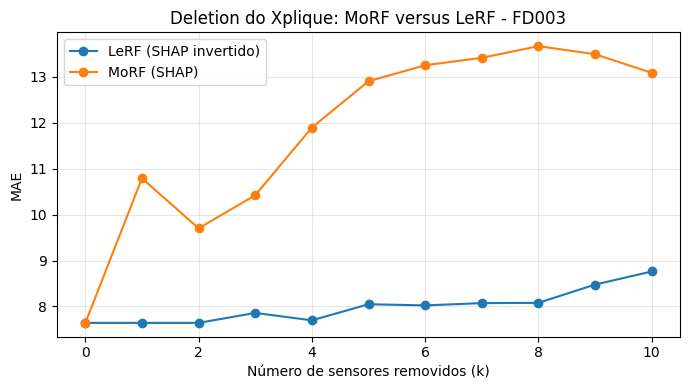

In [20]:
X_train_fd003 = np.load('../../data/processed_data/X_train_FD003.npz')['dados']
shap_fd003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)

resultados_deletion_fd003, auc_deletion_fd003, diferenca_auc_deletion_fd003 = avaliar_deletion_morf_lerf(
    shap_fd003, X_train_fd003, num_instancias=NUM_INSTANCIAS, max_k=MAX_K
)

display(auc_deletion_fd003.round(3))
print(f'Diferença AUC MoRF - LeRF: {diferenca_auc_deletion_fd003:.4f}')
plotar_deletion_morf_lerf(resultados_deletion_fd003, 'FD003')

### Análise - FD003

No FD003, MoRF apresentou AUC de MAE de 0,569 e LeRF de 0,043, diferença de 0,526. Esta é uma das maiores separações observadas. Mesmo com oscilações pontuais na curva, a AUC resume o efeito acumulado e confirma que remover os sensores mais importantes prejudica muito mais o modelo. Os valores coincidem com o notebook 03.

,Estratégia,AUC do aumento relativo de MAE
0,LeRF (SHAP invertido),0.006
1,MoRF (SHAP),0.543


Diferença AUC MoRF - LeRF: 0.5373


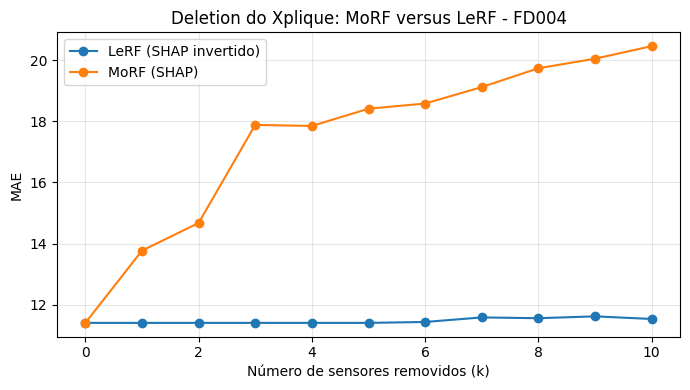

In [21]:
X_train_fd004 = np.load('../../data/processed_data/X_train_FD004.npz')['dados']
shap_fd004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)

resultados_deletion_fd004, auc_deletion_fd004, diferenca_auc_deletion_fd004 = avaliar_deletion_morf_lerf(
    shap_fd004, X_train_fd004, num_instancias=NUM_INSTANCIAS, max_k=MAX_K
)

display(auc_deletion_fd004.round(3))
print(f'Diferença AUC MoRF - LeRF: {diferenca_auc_deletion_fd004:.4f}')
plotar_deletion_morf_lerf(resultados_deletion_fd004, 'FD004')

### Análise - FD004

No FD004, a AUC de MoRF foi 0,543 e a de LeRF 0,006, resultando em diferença de 0,537, a maior entre os quatro datasets. Assim, a remoção dos sensores menos importantes praticamente não altera o erro, enquanto a remoção dos mais importantes produz efeito acumulado forte. O notebook 03 apresentou os mesmos resultados.

### Análise geral - comparação entre as duas avaliações de Fidelity

| Dataset | AUC MoRF | AUC LeRF | Diferença MoRF - LeRF |
|---|---:|---:|---:|
| FD001 | 0,087 | 0,011 | 0,076 |
| FD002 | 0,221 | 0,003 | 0,218 |
| FD003 | 0,569 | 0,043 | 0,526 |
| FD004 | 0,543 | 0,006 | 0,537 |

Com as mesmas 1000 janelas, o mesmo ranking global SHAP, a mesma máscara de mediana e o mesmo intervalo de remoção, o Xplique reproduziu as AUCs do notebook 03. Isso verifica que a implementação própria de MoRF/LeRF está consistente com a implementação Deletion da biblioteca.

Em todos os datasets, a AUC de MoRF foi maior que a de LeRF. A separação foi menor no FD001, intermediária no FD002 e mais forte no FD003 e FD004. Isso sustenta a Fidelity do ranking global SHAP: os sensores apontados como mais importantes são justamente os que mais pioram o MAE quando mascarados. Como os dois notebooks agora executam essencialmente o mesmo protocolo, essa comparação deve ser apresentada como validação da implementação, e não como uma avaliação independente adicional da qualidade do SHAP.

### Complemento: curvas de remoção progressiva do notebook 03

A análise foi ampliada removendo de 0 a 10 sensores do ranking global SHAP. As curvas reforçam a conclusão de Fidelity global: o MAE aumentou de 10,097 para 18,162 no FD001, de 12,255 para 20,161 no FD002 e de 12,896 para 18,915 no FD004. No FD003, o maior MAE ocorreu com Top-8 (12,398), permanecendo bem acima do valor original de 7,110.

FD001 e FD002 apresentam crescimento praticamente contínuo do erro. No FD003 há oscilações na curva, e no FD004 uma pequena diferença entre Top-4 e Top-5; isso é esperado porque, em uma rede não linear, os efeitos de mascarar sensores não são necessariamente aditivos. Essas oscilações não mudam a conclusão global dos gráficos, mas deverão ser observadas também na comparação entre as AUCs MoRF e LeRF calculadas pelo Xplique.

## 2. Infidelity: comparação entre ruído gaussiano e Quantus

Comparamos a **Infidelity própria** do notebook 03 com a **Infidelity do Quantus** usando as mesmas 50 janelas de teste e os mesmos coeficientes LIME. Ambos medem o erro quadrático entre a mudança estimada pela explicação e a mudança real da previsão. A diferença está nas perturbações:

| Aspecto | Infidelity própria | Quantus |
|---|---|---|
| Perturbação | 50 ruídos gaussianos por janela, desvio-padrão 0,05 | Substituição cumulativa por zero |
| Unidade alterada | Todas as posições recebem pequenos ruídos | Uma posição ciclo × sensor por etapa (bloco 1 × 1) |
| Extensão | Vizinhança local, sem recorte dos valores | Da primeira posição até toda a janela substituída |
| Ordem | Ruídos sorteados com semente 42 | Ordem fixa dos ciclos e sensores da entrada |
| Repetições | 50 perturbações diferentes | Uma passagem completa e determinística |

A implementação instalada do Quantus foi feita para imagens. Adaptamos cada janela para um mapa tempo × sensor com um canal, preservando as previsões da CNN-LSTM. Usamos blocos 1 × 1 porque os FDs têm quantidades diferentes de sensores e não há vizinhança espacial natural entre eles. A ordem das colunas permanece fixa e pode influenciar a trajetória cumulativa.

No Quantus, o baseline é **zero na escala processada**, não a mediana nem ausência física do sensor. Mantemos os coeficientes LIME com sinal, ajustados pela escala interna do LIME: abs=False e normalise=False. Uma única passagem é suficiente porque repetir a mesma remoção determinística não gera novas perturbações. São tempo × sensores etapas por janela, não apenas uma perturbação.

Mantemos background LIME de 500 janelas, 2.000 amostras por explicação, discretize_continuous=False e semente 42. A Infidelity própria é recalculada aqui junto ao Quantus para compartilhar exatamente as mesmas explicações.

**Como interpretar:** verificaremos se os FDs com menor ou maior Infidelity própria apresentam padrão semelhante no Quantus. Os valores absolutos não precisam coincidir, e sua magnitude não define qual teste é melhor. O teste próprio avalia mudanças locais; o Quantus testa a explicação também sob mudanças amplas, que podem sair da distribuição dos dados. Concordância sugere consistência entre os protocolos; divergência revela dependência da perturbação. Nenhum dos casos, sozinho, comprova a qualidade geral do LIME.

Referência: [Quantus — Infidelity](https://quantus.readthedocs.io/en/latest/docs_api/quantus.metrics.faithfulness.infidelity.html).


In [22]:
from quantus import Infidelity as InfidelityQuantus
from importlib.metadata import version

print('Versão do Quantus:', version('quantus'))
CONFIG_INF_VALIDACAO = dict(
    num_instancias=50, num_perturbacoes=50,
    sigma=0.05, num_amostras_lime=2000, seed=42,
)


Versão do Quantus: 0.6.0


In [23]:
class ModeloRULQuantus(tf.keras.Model):
    """Modelo funcional com inferência direta para os pequenos lotes do Quantus."""
    def predict(self, x, **kwargs):
        # O Quantus controla o tamanho dos lotes; evitamos criar um Dataset por etapa.
        return self(x, training=False).numpy()


def criar_modelo_infidelity_quantus(modelo, formato):
    """Adiciona um canal ao mapa tempo x sensor sem alterar a previsão."""
    entrada = tf.keras.Input(shape=(*formato, 1))
    janela = tf.keras.layers.Reshape(formato)(entrada)
    previsao = modelo(janela, training=False)
    # Quantus inspeciona a ativação da última camada. RUL mantém saída linear.
    saida = tf.keras.layers.Activation('linear')(previsao)
    return ModeloRULQuantus(inputs=entrada, outputs=saida)


def avaliar_infidelity_quantus(explainer, num_instancias=50, num_perturbacoes=50,
                               sigma=0.05, num_amostras_lime=2000, seed=42):
    """Mesmas explicações LIME, dois protocolos distintos de perturbação."""
    if num_instancias < 1 or num_perturbacoes < 1 or sigma < 0:
        raise ValueError('Use quantidades positivas e sigma não negativo.')
    if explainer.explainer.mode != 'regression' or explainer.explainer.discretizer is not None:
        raise ValueError('Use LIME em regressão com discretize_continuous=False.')

    rng = np.random.default_rng(seed)
    estado_lime = np.random.RandomState(seed)
    explainer.explainer.random_state = estado_lime
    explainer.explainer.base.random_state = estado_lime
    n = min(num_instancias, len(explainer.X_test))
    n_tempo, n_sensores = explainer.X_test.shape[1:]
    X = explainer.X_test[:n].astype(np.float32)
    escala = np.asarray(explainer.explainer.scaler.scale_).copy()
    escala[escala == 0] = 1.0
    coeficientes = []
    resultados = []

    for indice, x in enumerate(X):
        explicacao = explainer.explain_instance(
            indice, num_features=n_tempo * n_sensores,
            num_samples=num_amostras_lime,
        )
        pesos = np.zeros(n_tempo * n_sensores)
        for feature, peso in explicacao.local_exp[1]:
            pesos[int(feature)] = peso
        # LIME armazena sensor x tempo; a rede recebe tempo x sensor.
        coeficientes.append((pesos / escala).reshape(n_sensores, n_tempo).T)

        ruido = rng.normal(0, sigma, size=(num_perturbacoes, n_tempo, n_sensores))
        pred_original = explainer.model.predict(x[None], verbose=0).reshape(-1)[0]
        pred_perturbada = explainer.model.predict(x[None] - ruido, verbose=0).reshape(-1)
        mudanca_real = pred_original - pred_perturbada
        ruido_lime = ruido.transpose(0, 2, 1).reshape(num_perturbacoes, -1)
        mudanca_estimada = (ruido_lime / escala) @ pesos
        resultados.append({
            'Amostra': indice,
            'Infidelity própria': float(np.mean((mudanca_estimada - mudanca_real) ** 2)),
            'R² local LIME': explicacao.score,
        })
        if (indice + 1) % 10 == 0 or indice + 1 == n:
            print(f'LIME e Infidelity própria: {indice + 1}/{n} janelas')

    modelo_quantus = criar_modelo_infidelity_quantus(explainer.model, X.shape[1:])
    X_quantus = X[..., None]  # Modelo recebe N x tempo x sensor x canal.
    atribuicoes = np.asarray(coeficientes)[:, None, :, :]  # Quantus recebe N x canal x tempo x sensor.
    np.testing.assert_allclose(
        modelo_quantus.predict(X_quantus).reshape(-1),
        explainer.model.predict(X, verbose=0).reshape(-1),
        rtol=1e-5, atol=1e-5,
        err_msg='O adaptador mudou as previsões da rede.',
    )

    metrica = InfidelityQuantus(
        perturb_patch_sizes=[1], n_perturb_samples=1,
        perturb_baseline=0.0, abs=False, normalise=False,
        return_aggregate=False, disable_warnings=True,
        display_progressbar=True,
    )
    print(f'Quantus: {n_tempo * n_sensores} etapas cumulativas para {n} janelas.')
    valores_quantus = metrica(
        model=modelo_quantus, x_batch=X_quantus,
        # y_batch seleciona a única saída da rede (RUL), não os rótulos reais.
        y_batch=np.zeros(n, dtype=int), a_batch=atribuicoes,
        channel_first=False, softmax=False, batch_size=n,
        model_predict_kwargs={'verbose': 0},
    )
    valores_quantus = np.asarray(valores_quantus, dtype=float).reshape(-1)
    if len(valores_quantus) != n or not np.isfinite(valores_quantus).all():
        raise ValueError('Quantus retornou quantidade incorreta ou valores não finitos.')

    resultados = pd.DataFrame(resultados)
    resultados.insert(2, 'Infidelity Quantus', valores_quantus)
    resumo = resultados.drop(columns='Amostra').agg(['mean', 'std', 'median'])
    return resultados, resumo


In [24]:
lime_validacao_fd001 = LimeExplainer(
    model_path_001, x_path_001, y_path_001,
    background_size=500, discretize_continuous=False, random_state=42,
)
resultados_inf_validacao_fd001, resumo_inf_validacao_fd001 = avaliar_infidelity_quantus(
    lime_validacao_fd001, **CONFIG_INF_VALIDACAO
)
display(resumo_inf_validacao_fd001.round(6))


LIME e Infidelity própria: 10/50 janelas
LIME e Infidelity própria: 20/50 janelas
LIME e Infidelity própria: 30/50 janelas
LIME e Infidelity própria: 40/50 janelas
LIME e Infidelity própria: 50/50 janelas
Quantus: 570 etapas cumulativas para 50 janelas.


  0%|          | 0/1.0 [00:00<?, ?it/s]

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\quantus\helpers\warn.py:257: UserWarning: The settings for perturbing input e.g., 'perturb_func' didn't cause change in input. Reconsider the parameter settings.
  warnings.warn(


,Infidelity própria,Infidelity Quantus,R² local LIME
mean,16.940972,440.267163,0.881603
std,5.949901,352.213365,0.005447
median,16.578548,365.400618,0.881327


### Análise - FD001

O FD001 apresentou Infidelity própria média de 16,941 e Infidelity Quantus de 440,267. Ficou na segunda posição, do menor para o maior erro, nos dois protocolos. As medianas foram 16,579 e 365,401, respectivamente. Há concordância na posição relativa deste FD, mas a dispersão no Quantus foi maior (desvio-padrão de 352,213), mostrando diferenças consideráveis entre as janelas sob substituição cumulativa. Os valores absolutos dos protocolos não devem ser interpretados como uma comparação de desempenho entre bibliotecas.


In [25]:
lime_validacao_fd002 = LimeExplainer(
    model_path_002, x_path_002, y_path_002,
    background_size=500, discretize_continuous=False, random_state=42,
)
resultados_inf_validacao_fd002, resumo_inf_validacao_fd002 = avaliar_infidelity_quantus(
    lime_validacao_fd002, **CONFIG_INF_VALIDACAO
)
display(resumo_inf_validacao_fd002.round(6))


LIME e Infidelity própria: 10/50 janelas
LIME e Infidelity própria: 20/50 janelas
LIME e Infidelity própria: 30/50 janelas
LIME e Infidelity própria: 40/50 janelas
LIME e Infidelity própria: 50/50 janelas
Quantus: 720 etapas cumulativas para 50 janelas.


  0%|          | 0/1.0 [00:00<?, ?it/s]

,Infidelity própria,Infidelity Quantus,R² local LIME
mean,13.95901,798.670804,0.850275
std,5.65000,265.920297,0.006465
median,12.46850,762.486759,0.849287


### Análise - FD002

O FD002 apresentou a menor Infidelity própria (média 13,959; mediana 12,469), mas a maior no Quantus (média 798,671; mediana 762,487). A inversão também aparece nas medianas, portanto não é explicada apenas por poucos valores extremos. Nas janelas avaliadas, os pesos LIME tiveram o menor erro para o ruído gaussiano e o maior para a trajetória de substituição por zero. Isso é compatível com uma aproximação que funciona melhor localmente do que sob alterações amplas, mas não identifica a causa da divergência. O Quantus não confirmou a posição favorável do FD002 observada no teste próprio.


In [26]:
lime_validacao_fd003 = LimeExplainer(
    model_path_003, x_path_003, y_path_003,
    background_size=500, discretize_continuous=False, random_state=42,
)
resultados_inf_validacao_fd003, resumo_inf_validacao_fd003 = avaliar_infidelity_quantus(
    lime_validacao_fd003, **CONFIG_INF_VALIDACAO
)
display(resumo_inf_validacao_fd003.round(6))


LIME e Infidelity própria: 10/50 janelas
LIME e Infidelity própria: 20/50 janelas
LIME e Infidelity própria: 30/50 janelas
LIME e Infidelity própria: 40/50 janelas
LIME e Infidelity própria: 50/50 janelas
Quantus: 600 etapas cumulativas para 50 janelas.


  0%|          | 0/1.0 [00:00<?, ?it/s]

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\quantus\helpers\warn.py:257: UserWarning: The settings for perturbing input e.g., 'perturb_func' didn't cause change in input. Reconsider the parameter settings.
  warnings.warn(


,Infidelity própria,Infidelity Quantus,R² local LIME
mean,55.078412,547.870603,0.874683
std,17.531937,510.936749,0.005488
median,50.960144,386.834454,0.874921


### Análise - FD003

O FD003 teve a maior Infidelity própria, com média de 55,078 e mediana de 50,960. Como a mediana também é alta, a diferença em relação aos demais FDs não parece restrita a poucos casos extremos. Esses números medem erro quadrático ao estimar mudanças do RUL, não o erro da previsão de RUL contra o valor real. No Quantus, a média foi 547,871, a segunda maior, mas com mediana de 386,834 e desvio-padrão de 510,937, indicando resultados bastante heterogêneos. Os dois protocolos colocaram o FD003 entre os maiores erros relativos aos demais FDs. O R² local de 0,875 não contradiz esse resultado, pois avalia o ajuste em outra vizinhança.


In [27]:
lime_validacao_fd004 = LimeExplainer(
    model_path_004, x_path_004, y_path_004,
    background_size=500, discretize_continuous=False, random_state=42,
)
resultados_inf_validacao_fd004, resumo_inf_validacao_fd004 = avaliar_infidelity_quantus(
    lime_validacao_fd004, **CONFIG_INF_VALIDACAO
)
display(resumo_inf_validacao_fd004.round(6))


LIME e Infidelity própria: 10/50 janelas
LIME e Infidelity própria: 20/50 janelas
LIME e Infidelity própria: 30/50 janelas
LIME e Infidelity própria: 40/50 janelas
LIME e Infidelity própria: 50/50 janelas
Quantus: 720 etapas cumulativas para 50 janelas.


  0%|          | 0/1.0 [00:00<?, ?it/s]

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\quantus\helpers\warn.py:257: UserWarning: The settings for perturbing input e.g., 'perturb_func' didn't cause change in input. Reconsider the parameter settings.
  warnings.warn(


,Infidelity própria,Infidelity Quantus,R² local LIME
mean,17.538932,391.993885,0.690298
std,3.395652,228.413592,0.010473
median,16.991432,329.279087,0.690534


### Análise - FD004

O FD004 apresentou Infidelity própria média de 17,539, a terceira menor, enquanto no Quantus obteve a menor média (391,994) e mediana (329,279). Portanto, sua posição relativa também mudou com o protocolo de perturbação. Isso não permite concluir que seja o FD mais explicável: o erro absoluto depende tanto dos coeficientes LIME quanto das mudanças da previsão ao longo da trajetória. O R² médio de 0,690 foi o menor entre os FDs e continua indicando um ajuste menos preciso na vizinhança do LIME.


In [28]:
comparacao_infidelity = pd.DataFrame([
    {
        'Dataset': nome,
        'Infidelity própria': dados['Infidelity própria'].mean(),
        'Infidelity Quantus': dados['Infidelity Quantus'].mean(),
        'Mediana própria': dados['Infidelity própria'].median(),
        'Mediana Quantus': dados['Infidelity Quantus'].median(),
        'R² médio LIME': dados['R² local LIME'].mean(),
    }
    for nome, dados in [
        ('FD001', resultados_inf_validacao_fd001),
        ('FD002', resultados_inf_validacao_fd002),
        ('FD003', resultados_inf_validacao_fd003),
        ('FD004', resultados_inf_validacao_fd004),
    ]
]).set_index('Dataset')
comparacao_infidelity['Posição própria (menor = 1)'] = comparacao_infidelity['Infidelity própria'].rank()
comparacao_infidelity['Posição Quantus (menor = 1)'] = comparacao_infidelity['Infidelity Quantus'].rank()
display(comparacao_infidelity.round(6))
concordancia_fds = comparacao_infidelity['Posição própria (menor = 1)'].corr(
    comparacao_infidelity['Posição Quantus (menor = 1)']
)
print(f'Concordância descritiva das ordenações (Spearman, apenas 4 FDs): {concordancia_fds:.3f}')
print('Comparar os padrões; os valores absolutos pertencem a protocolos diferentes.')


,Infidelity própria,Infidelity Quantus,Mediana própria,Mediana Quantus,R² médio LIME,Posição própria (menor = 1),Posição Quantus (menor = 1)
Dataset,,,,,,,
FD001,16.940972,440.267163,16.578548,365.400618,0.881603,2.0,2.0
FD002,13.959010,798.670804,12.468500,762.486759,0.850275,1.0,4.0
FD003,55.078412,547.870603,50.960144,386.834454,0.874683,4.0,3.0
FD004,17.538932,391.993885,16.991432,329.279087,0.690298,3.0,1.0


Concordância descritiva das ordenações (Spearman, apenas 4 FDs): -0.400
Comparar os padrões; os valores absolutos pertencem a protocolos diferentes.


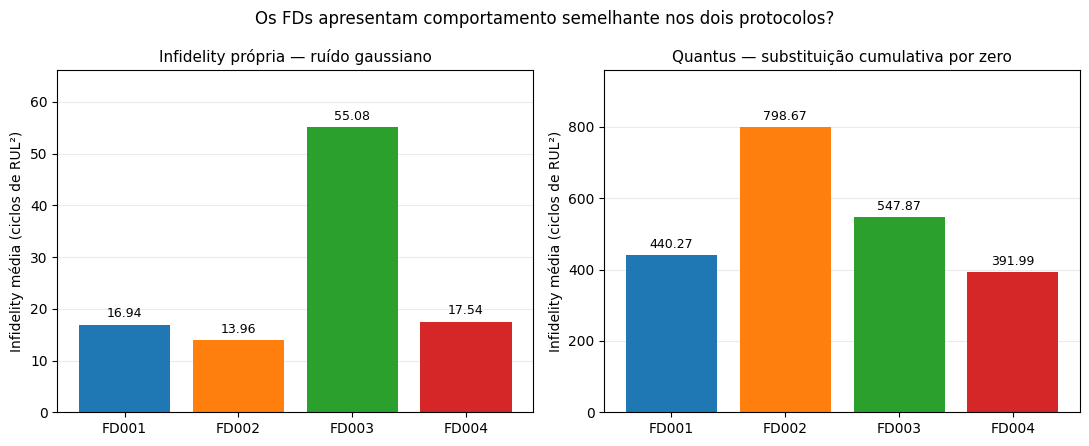

In [29]:
# Dois painéis com escalas próprias, pois os protocolos têm magnitudes diferentes.
from pathlib import Path

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))
for eixo, coluna, titulo in zip(
    eixos, ['Infidelity própria', 'Infidelity Quantus'],
    ['Infidelity própria — ruído gaussiano', 'Quantus — substituição cumulativa por zero'],
):
    barras = eixo.bar(
        comparacao_infidelity.index, comparacao_infidelity[coluna],
        color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'],
    )
    eixo.bar_label(barras, fmt='%.2f', padding=3, fontsize=9)
    eixo.set_title(titulo, fontsize=11)
    eixo.set_ylabel('Infidelity média (ciclos de RUL²)')
    eixo.set_ylim(0, max(comparacao_infidelity[coluna].max() * 1.2, 1e-12))
    eixo.grid(axis='y', alpha=0.25)
    eixo.set_axisbelow(True)
fig.suptitle('Os FDs apresentam comportamento semelhante nos dois protocolos?')
fig.tight_layout()
pasta_figuras = Path('figuras')
pasta_figuras.mkdir(exist_ok=True)
fig.savefig(pasta_figuras / 'validacao_infidelity_quantus.png', dpi=180, bbox_inches='tight')
plt.show()


### Análise geral - Infidelity

| Dataset | Infidelity própria — média | Infidelity Quantus — média | Posição própria → Quantus (menor = 1) |
|---|---:|---:|---:|
| FD001 | 16,941 | 440,267 | 2 → 2 |
| FD002 | 13,959 | 798,671 | 1 → 4 |
| FD003 | 55,078 | 547,871 | 4 → 3 |
| FD004 | 17,539 | 391,994 | 3 → 1 |

As ordenações não foram consistentes entre os protocolos: a correlação de Spearman foi −0,400, um resumo apenas descritivo dos quatro FDs. O FD001 manteve a segunda posição e o FD003 permaneceu entre os maiores erros, mas FD002 e FD004 mudaram bastante. Portanto, o Quantus não confirmou a ordenação global observada na Infidelity própria.

Essa divergência é numericamente plausível porque o teste próprio aplica ruído gaussiano de desvio-padrão 0,05, enquanto o Quantus substitui cumulativamente a entrada por zero até alterar toda a janela. Uma explicação linear local não precisa manter a mesma precisão nessa trajetória. O baseline, a ordem das posições, a amplitude das alterações e possíveis entradas fora da distribuição podem influenciar o resultado. São hipóteses explicativas; este experimento não isolou o efeito de cada uma.

No FD003, a Infidelity própria elevada representa maior erro ao estimar a mudança da previsão neste protocolo. Ela não demonstra, sozinha, pior acurácia da rede ou maior complexidade como causa. A medida está em ciclos de RUL ao quadrado e depende da escala das respostas do modelo. Sem uma referência adicional, não há um limiar universal para classificar os valores como bons ou ruins.

A conclusão é que a avaliação das explicações LIME depende do tipo de perturbação. O resultado deve ser apresentado como uma comparação de sensibilidade a dois protocolos, com concordância parcial e divergências relevantes. As conclusões se limitam às primeiras 50 janelas de cada FD, que não necessariamente representam todos os motores ou estágios de degradação.

A Infidelity própria desta seção reproduz a fórmula do notebook 03 com os mesmos parâmetros. Antes de comparar com saídas históricas daquele notebook, execute sua seção de Infidelity com a versão atual das funções.

O aviso do Quantus de que uma perturbação não alterou a entrada indica que, em alguma etapa, a janela permaneceu numericamente próxima da original. Com baseline zero, isso pode acontecer quando as primeiras posições substituídas já são zero ou muito próximas de zero. Não significa que toda a avaliação tenha deixado de perturbar os dados; essas etapas sem alteração também fazem parte da média calculada.
